# Exercise 1
Part 1 - Flat data and headers
This script creates the new file with the following features:

a proper name, helping to know what the content is
a first row with the name of each column and the units


In [4]:
import pandas as pd

# Define your headers
headers = ["Date", "Time", "Depth_m", "Temperature_C", "Salinity_psu"]

# Read the tab-separated file with headers
df = pd.read_csv("for_nitpicker.dat", sep="\t", header=None, names=headers)

print(df.head())

# Save the DataFrame as a CSV file
df.to_csv("cleaned_ctd.csv", index=False)



         Date   Time  Depth_m  Temperature_C  Salinity_psu
0  11/29/2008  06:52        5          28.97         35.21
1  11/29/2008  06:52        6          28.98         35.21
2  11/29/2008  06:52        7          28.99         35.21
3  11/29/2008  06:52        8          28.96         35.21
4  11/29/2008  06:52        9          28.99         35.21


# Part 2 - profiles
This script creates a two-panels plot showing temperature and salinity profiles from the prepared file in part 1.

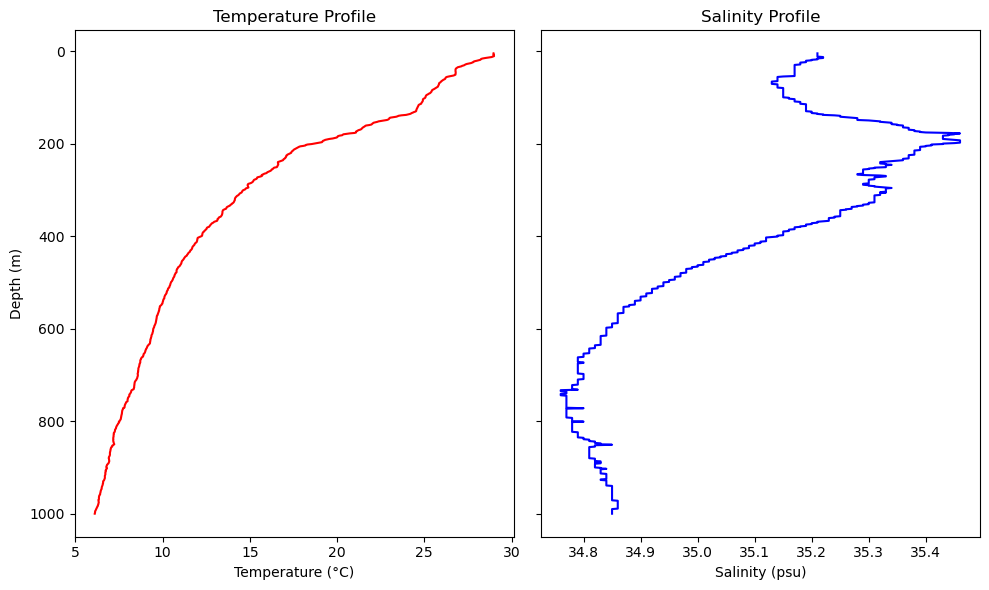

<Figure size 640x480 with 0 Axes>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned file you saved earlier
df = pd.read_csv("cleaned_ctd.csv")

# Create the figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Temperature profile
ax1.plot(df["Temperature_C"], df["Depth_m"], color="red", linestyle="-")
ax1.set_xlabel("Temperature (°C)")
ax1.set_ylabel("Depth (m)")
ax1.set_title("Temperature Profile")

# Salinity profile
ax2.plot(df["Salinity_psu"], df["Depth_m"], color="blue", linestyle="-")
ax2.set_xlabel("Salinity (psu)")
ax2.set_title("Salinity Profile")

ax1.invert_yaxis()
plt.tight_layout()
plt.show()

# Invert y-axis so depth increases downward
ax1.invert_yaxis()

plt.tight_layout()
plt.show()


# Part 3: Time series
This script do the following operations

* Load the CSV file in python, using the appropriate column for the time index. Check that the missing values are properly recognized. The ship reached the southernmost location on July 4th. Use the time indexing to select the data from departure to that date included. All plots will be done using this selected set of data.
* Plot the time series of temperature with the appropriate labels. Save the figure using the 'grayscale' style
* Plot a histogram of the salinity distribution using bins of 0.5 psu between 30 and 35.
* Calculate the mean, standard deviation and the interquartile range for temperature and salinity and present the results in a table.
* Create a scatter plot of wind speed and air temperature, encoding the latitude information in colour. Wind speed is in meters per second and air temperature in degrees Celsius. Save this figure in PNG with a resolution of 300 DPI

In [1]:
import pandas as pd

df = pd.read_csv("SAA2_WC_2017_metocean_10min_avg.csv")
print(df.head())
print(df.columns)

     id       TIME_SERVER  TIME_GPS  LATITUDE N_S  LONGITUDE E_W  HUMIDITY  \
0  1256  2017/06/28 17:10  17:09:58  3428.595   S   1819.447   E      73.2   
1  1257  2017/06/28 17:20  17:19:58  3430.443   S   1820.241   E      65.2   
2  1258  2017/06/28 17:30  17:29:59  3432.261   S   1821.118   E      68.0   
3  1259  2017/06/28 17:40  17:40:02  3434.121   S   1821.882   E      68.0   
4  1260  2017/06/28 17:50  17:49:58  3435.981   S   1822.673   E      65.4   

   BAROMETER  AIR_TEMPERATURE  WIND_SPEED_REL  WIND_SPEED_TRUE  WIND_DIR_REL  \
0     1.0175             12.5             6.7              5.9          20.8   
1     1.0174             12.7             6.3              7.7          31.8   
2     1.0179             12.8             7.4              4.9          14.9   
3     1.0180             12.8             7.4              5.8          29.4   
4     1.0180             12.7             6.4              7.2          24.5   

   WIND_DIR_TRUE    PAR  TSG_SALINITY  TSG_TEMP  


In [2]:
df = pd.read_csv(
    "SAA2_WC_2017_metocean_10min_avg.csv",
    parse_dates=["TIME_SERVER"],
    index_col="TIME_SERVER"
)

In [3]:
subset = df.loc[:'2017-07-04']

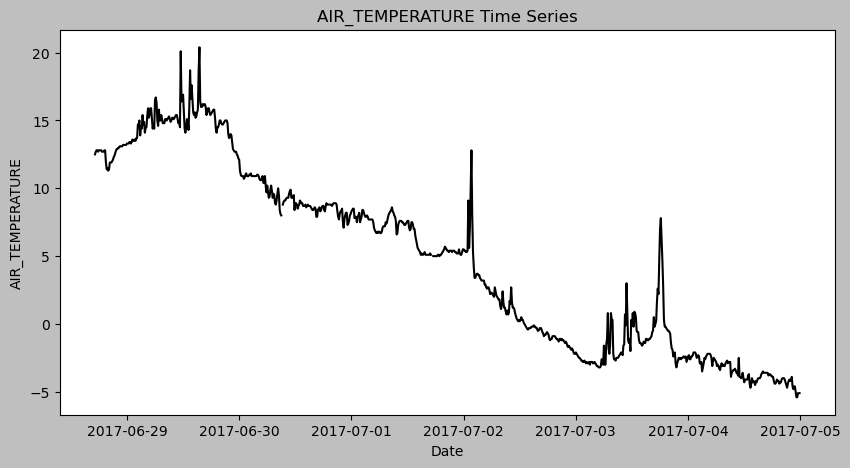

In [4]:
import matplotlib.pyplot as plt
plt.style.use('grayscale')

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(subset.index, subset["AIR_TEMPERATURE"], linestyle="-")
ax.set_xlabel("Date")
ax.set_ylabel("AIR_TEMPERATURE")
ax.set_title("AIR_TEMPERATURE Time Series")
fig.savefig("AIR_TEMPERATURE_timeseries.png", dpi=300)
plt.show()


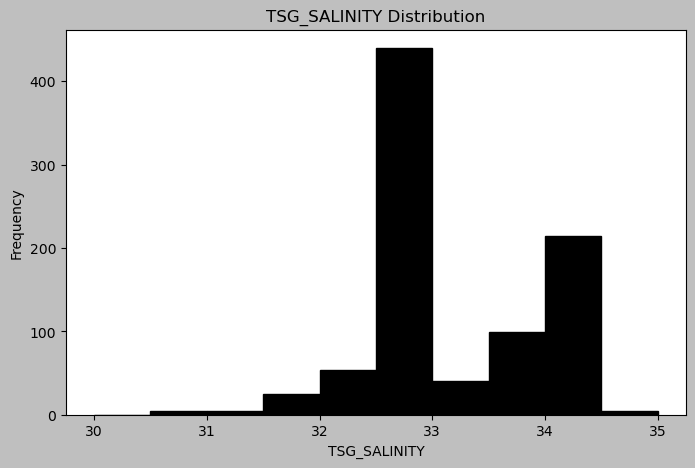

In [5]:
import numpy as np

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(subset["TSG_SALINITY"], bins=np.arange(30, 35.5, 0.5), edgecolor="black")
ax.set_xlabel("TSG_SALINITY")
ax.set_ylabel("Frequency")
ax.set_title("TSG_SALINITY Distribution")
plt.show()

In [6]:
summary = pd.DataFrame({
    "Mean": [subset["AIR_TEMPERATURE"].mean(), subset["TSG_SALINITY"].mean()],
    "Std Dev": [subset["AIR_TEMPERATURE"].std(), subset["TSG_SALINITY"].std()],
    "IQR": [
        subset["AIR_TEMPERATURE"].quantile(0.75) - subset["AIR_TEMPERATURE"].quantile(0.25),
        subset["TSG_SALINITY"].quantile(0.75) - subset["TSG_SALINITY"].quantile(0.25)
    ]
}, index=["AIR_TEMPERATURE", "TSG_SALINITY"])

print(summary)

                      Mean   Std Dev        IQR
AIR_TEMPERATURE   4.878271  6.692847  11.675000
TSG_SALINITY     33.110553  1.140150   1.272575


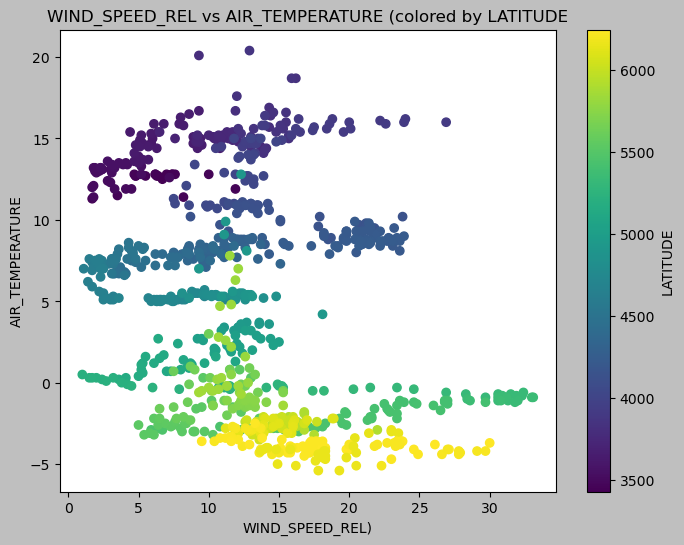

In [7]:
fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(subset["WIND_SPEED_REL"], subset["AIR_TEMPERATURE"], 
                c=subset["LATITUDE"], cmap="viridis")
ax.set_xlabel("WIND_SPEED_REL)")
ax.set_ylabel("AIR_TEMPERATURE")
ax.set_title("WIND_SPEED_REL vs AIR_TEMPERATURE (colored by LATITUDE")
plt.colorbar(sc, label="LATITUDE")
fig.savefig("scatter_wind_airtemp.png", dpi=300)
plt.show()